In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


In [2]:
# Input files for all available intensities and event classes
FILES = {
    1.0: {
        'all': Path('ECBB_model/1.0PW_cm^2/momenta_all_events.txt'),
        'direct': Path('ECBB_model/1.0PW_cm^2/momenta_direct_events.txt'),
        'delayed': Path('ECBB_model/1.0PW_cm^2/momenta_delayed_events.txt'),
    },
    1.3: {
        'all': Path('ECBB_model/1.3PW_cm^2/momenta_all_events.txt'),
        'direct': Path('ECBB_model/1.3PW_cm^2/momenta_direct_events.txt'),
        'delayed': Path('ECBB_model/1.3PW_cm^2/momenta_delayed_events.txt'),
    },
    1.6: {
        'all': Path('ECBB_model/1.6PW_cm^2/momenta_all_events.txt'),
        'direct': Path('ECBB_model/1.6PW_cm^2/momenta_direct_events.txt'),
        'delayed': Path('ECBB_model/1.6PW_cm^2/momenta_delayed_events.txt'),
    },
    1.7: {
        'all': Path('ECBB_model/data/data_Neon/ECBB_model/1.7PW_cm^2/momenta_all_events.txt'),
        'direct': Path('ECBB_model/data/data_Neon/ECBB_model/1.7PW_cm^2/momenta_direct_events.txt'),
        'delayed': Path('ECBB_model/data/data_Neon/ECBB_model/1.7PW_cm^2/momenta_delayed_events.txt'),
    },
}

DATASETS = [
    {
        'intensity': float(intensity),
        'event_class': event_class,
        'path': path,
        'label': f'I={intensity:g} {event_class}',
    }
    for intensity, classes in FILES.items()
    for event_class, path in classes.items()
]

dataset_table = pd.DataFrame(DATASETS)
dataset_table['exists'] = dataset_table['path'].map(Path.exists)
display(dataset_table)

missing = dataset_table.loc[~dataset_table['exists'], 'path'].tolist()
if missing:
    raise FileNotFoundError('Missing input files:\n' + '\n'.join(map(str, missing)))


,intensity,event_class,path,label,exists
0,1.0,all,ECBB_model\1.0PW_cm^2\momenta_all_events.txt,I=1 all,True
1,1.0,direct,ECBB_model\1.0PW_cm^2\momenta_direct_events.txt,I=1 direct,True
2,1.0,delayed,ECBB_model\1.0PW_cm^2\momenta_delayed_events.txt,I=1 delayed,True
3,1.3,all,ECBB_model\1.3PW_cm^2\momenta_all_events.txt,I=1.3 all,True
4,1.3,direct,ECBB_model\1.3PW_cm^2\momenta_direct_events.txt,I=1.3 direct,True
5,1.3,delayed,ECBB_model\1.3PW_cm^2\momenta_delayed_events.txt,I=1.3 delayed,True
6,1.6,all,ECBB_model\1.6PW_cm^2\momenta_all_events.txt,I=1.6 all,True
7,1.6,direct,ECBB_model\1.6PW_cm^2\momenta_direct_events.txt,I=1.6 direct,True
8,1.6,delayed,ECBB_model\1.6PW_cm^2\momenta_delayed_events.txt,I=1.6 delayed,True
9,1.7,all,ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^...,I=1.7 all,True


In [3]:
# Output settings
OUTPUT_DIR = Path('momentum_sharing_results')
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

BINS_1D = 80
BINS_2D = 120
DPI = 170
INTENSITIES = sorted(FILES)
EVENT_CLASSES = ['all', 'direct', 'delayed']


In [4]:
# Column order in the ECBB momentum files
COLUMN_NAMES = [
    'p1x', 'p1y', 'p1z',
    'p2x', 'p2y', 'p2z',
    'p3x', 'p3y', 'p3z',
    'p4x', 'p4y', 'p4z',
]

def read_momentum_file(path):
    path = Path(path)
    df = pd.read_csv(
        path, header=None, sep=r'[\s,]+', engine='python', comment='#'
    )
    df = df.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if df.shape[1] != 12:
        raise ValueError(f'Expected 12 columns, got {df.shape[1]} in {path}')
    df.columns = COLUMN_NAMES
    return df.astype(float)


In [ ]:
# Fixed orthonormal basis
e0 = np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0)
e1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
e2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)
HELMERT = np.vstack([e0, e1, e2])

display(pd.DataFrame(
    HELMERT @ HELMERT.T,
    index=['e0', 'e1', 'e2'],
    columns=['e0', 'e1', 'e2'],
))


,e0,e1,e2
e0,1.000000e+00,-1.779619e-17,-2.219433e-17
e1,-1.779619e-17,1.000000e+00,2.451427e-17
e2,-2.219433e-17,2.451427e-17,1.000000e+00


In [6]:
def sign_labels(values):
    values = np.asarray(values)
    signs = np.where(values > 0, '+', np.where(values < 0, '-', '0'))
    return np.array([''.join(row) for row in signs])

def process_dataset(df, intensity, event_class):
    out = df.copy()
    out['intensity'] = float(intensity)
    out['event_class'] = event_class

    p2 = out['p2z'].to_numpy()
    p3 = out['p3z'].to_numpy()
    p4 = out['p4z'].to_numpy()

    # Collective and relative coordinates
    out['P_e'] = p2 + p3 + p4
    out['Q'] = out['P_e'] / np.sqrt(3.0)
    out['xi1'] = (p2 - p3) / np.sqrt(2.0)
    out['xi2'] = (p2 + p3 - 2.0 * p4) / np.sqrt(6.0)
    out['K'] = np.sqrt(out['xi1']**2 + out['xi2']**2)
    out['phi'] = np.arctan2(out['xi2'], out['xi1'])

    # Relative deviations
    out['p_bar'] = out['P_e'] / 3.0
    out['q2'] = p2 - out['p_bar']
    out['q3'] = p3 - out['p_bar']
    out['q4'] = p4 - out['p_bar']

    # Orthogonality and inverse-transform checks
    out['norm_error'] = (
        p2**2 + p3**2 + p4**2
        - out['Q']**2 - out['xi1']**2 - out['xi2']**2
    )
    out['q_sum'] = out['q2'] + out['q3'] + out['q4']

    p2_rec = out['Q']/np.sqrt(3.0) + out['xi1']/np.sqrt(2.0) + out['xi2']/np.sqrt(6.0)
    p3_rec = out['Q']/np.sqrt(3.0) - out['xi1']/np.sqrt(2.0) + out['xi2']/np.sqrt(6.0)
    p4_rec = out['Q']/np.sqrt(3.0) - 2.0*out['xi2']/np.sqrt(6.0)

    out['p2_reconstruction_error'] = p2 - p2_rec
    out['p3_reconstruction_error'] = p3 - p3_rec
    out['p4_reconstruction_error'] = p4 - p4_rec

    # Normalized absolute momentum shares
    out['A'] = np.abs(p2) + np.abs(p3) + np.abs(p4)
    with np.errstate(divide='ignore', invalid='ignore'):
        out['x2'] = np.where(out['A'] > 0, np.abs(p2)/out['A'], np.nan)
        out['x3'] = np.where(out['A'] > 0, np.abs(p3)/out['A'], np.nan)
        out['x4'] = np.where(out['A'] > 0, np.abs(p4)/out['A'], np.nan)
        out['K_over_A'] = np.where(out['A'] > 0, out['K']/out['A'], np.nan)

    x = out[['x2', 'x3', 'x4']].to_numpy()
    out['N_eff'] = 1.0 / np.nansum(x**2, axis=1)
    out['x_max'] = np.nanmax(x, axis=1)

    eps = np.finfo(float).eps
    x_safe = np.clip(x, eps, None)
    out['entropy'] = -np.nansum(x*np.log(x_safe), axis=1) / np.log(3.0)

    # Sign sectors and ilr coordinates
    out['sign_sector'] = sign_labels(np.column_stack([p2, p3, p4]))
    out['ilr1'] = np.log(x_safe[:, 0]/x_safe[:, 1]) / np.sqrt(2.0)
    out['ilr2'] = np.log((x_safe[:, 0]*x_safe[:, 1])/(x_safe[:, 2]**2)) / np.sqrt(6.0)

    # Pairwise differences and total longitudinal momentum including the ion
    out['d23'] = p2 - p3
    out['d24'] = p2 - p4
    out['d34'] = p3 - p4
    out['P_total_z'] = out['p1z'] + out['P_e']

    return out


In [7]:
# Read and process all 12 datasets
processed = {}

for item in DATASETS:
    key = (item['intensity'], item['event_class'])
    raw = read_momentum_file(item['path'])
    processed[key] = process_dataset(raw, item['intensity'], item['event_class'])

combined = pd.concat(processed.values(), ignore_index=True)

sizes = (
    combined.groupby(['intensity', 'event_class'])
    .size()
    .rename('n')
    .reset_index()
)
display(sizes)


,intensity,event_class,n
0,1.0,all,4872
1,1.0,delayed,2097
2,1.0,direct,2042
3,1.3,all,13769
4,1.3,delayed,5837
5,1.3,direct,6198
6,1.6,all,18578
7,1.6,delayed,7560
8,1.6,direct,8799
9,1.7,all,3873


In [8]:
def centered_third_moment(df):
    p2 = df['p2z'] - df['p2z'].mean()
    p3 = df['p3z'] - df['p3z'].mean()
    p4 = df['p4z'] - df['p4z'].mean()
    return np.mean(p2*p3*p4)

def summary_row(df):
    corr = df[['p2z', 'p3z', 'p4z']].corr()
    sectors = df['sign_sector'].value_counts(normalize=True)

    r23 = corr.loc['p2z', 'p3z']
    r24 = corr.loc['p2z', 'p4z']
    r34 = corr.loc['p3z', 'p4z']

    return pd.Series({
        'n': len(df),
        'mean_P_e': df['P_e'].mean(),
        'std_P_e': df['P_e'].std(),
        'mean_K': df['K'].mean(),
        'std_K': df['K'].std(),
        'mean_K_over_A': df['K_over_A'].mean(),
        'mean_N_eff': df['N_eff'].mean(),
        'median_N_eff': df['N_eff'].median(),
        'mean_x_max': df['x_max'].mean(),
        'median_x_max': df['x_max'].median(),
        'mean_entropy': df['entropy'].mean(),
        'dominant_sector': sectors.index[0],
        'dominant_sector_fraction': sectors.iloc[0],
        'corr_p2_p3': r23,
        'corr_p2_p4': r24,
        'corr_p3_p4': r34,
        'mean_pair_correlation': np.mean([r23, r24, r34]),
        'kappa_234': centered_third_moment(df),
        'mean_P_total_z': df['P_total_z'].mean(),
        'std_P_total_z': df['P_total_z'].std(),
    })

summary = (
    combined.groupby(['intensity', 'event_class'], sort=True)
    .apply(summary_row)
    .reset_index()
)
display(summary)


,intensity,event_class,n,mean_P_e,std_P_e,mean_K,std_K,mean_K_over_A,mean_N_eff,median_N_eff,...,mean_entropy,dominant_sector,dominant_sector_fraction,corr_p2_p3,corr_p2_p4,corr_p3_p4,mean_pair_correlation,kappa_234,mean_P_total_z,std_P_total_z
0,1.0,all,4872,-0.079612,5.408208,1.735426,0.931375,0.340821,2.462402,2.540058,...,0.869494,---,0.329228,0.570522,0.588558,0.565182,0.574754,0.146742,0.010636,1.616733
1,1.0,delayed,2097,-0.162844,4.650714,2.120679,0.935148,0.411446,2.367489,2.369004,...,0.841947,---,0.246543,0.262689,0.428445,0.382426,0.357853,0.152310,0.027948,1.624344
2,1.0,direct,2042,-0.073247,6.657841,1.181807,0.523839,0.195891,2.661648,2.748623,...,0.929428,---,0.490695,0.867057,0.844206,0.833111,0.848125,0.142579,-0.022126,1.600255
3,1.3,all,13769,-0.012044,6.097410,1.821462,1.002500,0.328768,2.476870,2.554771,...,0.873750,---,0.335609,0.598776,0.615978,0.623153,0.612636,0.007068,-0.000172,1.675393
4,1.3,delayed,5837,0.079581,5.221820,2.275907,1.026086,0.409465,2.355027,2.358823,...,0.837939,+++,0.247559,0.267636,0.435030,0.458805,0.387157,-0.121516,-0.003780,1.693190
5,1.3,direct,6198,-0.124370,7.331980,1.295377,0.619234,0.200825,2.653533,2.748518,...,0.925974,---,0.485157,0.871030,0.830350,0.834403,0.845261,0.589494,-0.013411,1.678437
6,1.6,all,18578,-0.027843,6.479323,1.890832,1.041494,0.331898,2.482354,2.562269,...,0.876216,---,0.332974,0.613136,0.631753,0.631056,0.625315,0.014551,0.004935,1.634578
7,1.6,delayed,7560,-0.020681,5.510082,2.336604,1.103248,0.411096,2.366865,2.391298,...,0.842809,---,0.244444,0.269407,0.469574,0.464743,0.401242,0.024614,0.007850,1.634290
8,1.6,direct,8799,-0.041739,7.705175,1.417040,0.688122,0.218182,2.633123,2.733979,...,0.920070,---,0.456529,0.871940,0.813210,0.812987,0.832712,0.156598,0.003622,1.636115
9,1.7,all,3873,0.182760,6.246761,1.933103,1.078002,0.343181,2.468799,2.547081,...,0.872835,+++,0.325587,0.566514,0.609620,0.593941,0.590025,-0.142296,-0.014622,1.689367


In [9]:
# Numerical validation for every dataset
validation_rows = []
for (intensity, event_class), df in processed.items():
    validation_rows.append({
        'intensity': intensity,
        'event_class': event_class,
        'max_abs_norm_error': df['norm_error'].abs().max(),
        'max_abs_q_sum': df['q_sum'].abs().max(),
        'max_abs_p2_reconstruction_error': df['p2_reconstruction_error'].abs().max(),
        'max_abs_p3_reconstruction_error': df['p3_reconstruction_error'].abs().max(),
        'max_abs_p4_reconstruction_error': df['p4_reconstruction_error'].abs().max(),
    })

validation = pd.DataFrame(validation_rows).sort_values(['intensity', 'event_class'])
display(validation)


,intensity,event_class,max_abs_norm_error,max_abs_q_sum,max_abs_p2_reconstruction_error,max_abs_p3_reconstruction_error,max_abs_p4_reconstruction_error
0,1.0,all,1.820766e-14,1.776357e-15,1.332268e-15,1.332268e-15,1.776357e-15
2,1.0,delayed,1.204592e-14,1.332268e-15,1.332268e-15,1.332268e-15,1.332268e-15
1,1.0,direct,1.820766e-14,1.776357e-15,1.332268e-15,1.332268e-15,1.776357e-15
3,1.3,all,2.842171e-14,2.220446e-15,1.887379e-15,1.776357e-15,1.776357e-15
5,1.3,delayed,2.842171e-14,2.220446e-15,1.887379e-15,1.776357e-15,1.776357e-15
4,1.3,direct,2.398082e-14,1.776357e-15,1.776357e-15,1.776357e-15,1.776357e-15
6,1.6,all,3.241851e-14,2.220446e-15,1.776357e-15,1.776357e-15,1.776357e-15
8,1.6,delayed,2.764455e-14,1.998401e-15,1.776357e-15,1.776357e-15,1.776357e-15
7,1.6,direct,3.241851e-14,2.220446e-15,1.776357e-15,1.776357e-15,1.776357e-15
9,1.7,all,2.220446e-14,1.776357e-15,1.776357e-15,1.554312e-15,1.776357e-15


In [10]:
# Sign-sector fractions for every dataset
sector_counts = (
    combined.groupby(['intensity', 'event_class', 'sign_sector'])
    .size()
    .rename('count')
    .reset_index()
)
sector_counts['fraction'] = (
    sector_counts['count']
    / sector_counts.groupby(['intensity', 'event_class'])['count'].transform('sum')
)
display(sector_counts)

# Pairwise correlations in tidy form
correlation_rows = []
for (intensity, event_class), df in processed.items():
    corr = df[['p2z', 'p3z', 'p4z']].corr()
    correlation_rows.extend([
        {'intensity': intensity, 'event_class': event_class, 'pair': 'p2-p3', 'correlation': corr.loc['p2z', 'p3z']},
        {'intensity': intensity, 'event_class': event_class, 'pair': 'p2-p4', 'correlation': corr.loc['p2z', 'p4z']},
        {'intensity': intensity, 'event_class': event_class, 'pair': 'p3-p4', 'correlation': corr.loc['p3z', 'p4z']},
    ])

correlations = pd.DataFrame(correlation_rows).sort_values(['intensity', 'event_class', 'pair'])
display(correlations)


,intensity,event_class,sign_sector,count,fraction
0,1.0,all,+++,1546,0.317323
1,1.0,all,++-,246,0.050493
2,1.0,all,+-+,303,0.062192
3,1.0,all,+--,306,0.062808
4,1.0,all,-++,286,0.058703
...,...,...,...,...,...
91,1.7,direct,+--,20,0.011799
92,1.7,direct,-++,20,0.011799
93,1.7,direct,-+-,22,0.012979
94,1.7,direct,--+,43,0.025369


,intensity,event_class,pair,correlation
0,1.0,all,p2-p3,0.570522
1,1.0,all,p2-p4,0.588558
2,1.0,all,p3-p4,0.565182
6,1.0,delayed,p2-p3,0.262689
7,1.0,delayed,p2-p4,0.428445
8,1.0,delayed,p3-p4,0.382426
3,1.0,direct,p2-p3,0.867057
4,1.0,direct,p2-p4,0.844206
5,1.0,direct,p3-p4,0.833111
9,1.3,all,p2-p3,0.598776


In [11]:
# Direct-minus-delayed differences versus laser intensity
comparison_metrics = [
    'mean_K', 'mean_K_over_A', 'mean_N_eff',
    'mean_x_max', 'mean_entropy', 'mean_pair_correlation',
]

direct_delayed_rows = []
for intensity in INTENSITIES:
    current = summary[summary['intensity'] == intensity].set_index('event_class')
    row = {'intensity': intensity}
    for metric in comparison_metrics:
        row[f'direct_{metric}'] = current.loc['direct', metric]
        row[f'delayed_{metric}'] = current.loc['delayed', metric]
        row[f'direct_minus_delayed_{metric}'] = (
            current.loc['direct', metric] - current.loc['delayed', metric]
        )
    direct_delayed_rows.append(row)

direct_delayed = pd.DataFrame(direct_delayed_rows)
display(direct_delayed)


,intensity,direct_mean_K,delayed_mean_K,direct_minus_delayed_mean_K,direct_mean_K_over_A,delayed_mean_K_over_A,direct_minus_delayed_mean_K_over_A,direct_mean_N_eff,delayed_mean_N_eff,direct_minus_delayed_mean_N_eff,direct_mean_x_max,delayed_mean_x_max,direct_minus_delayed_mean_x_max,direct_mean_entropy,delayed_mean_entropy,direct_minus_delayed_mean_entropy,direct_mean_pair_correlation,delayed_mean_pair_correlation,direct_minus_delayed_mean_pair_correlation
0,1.0,1.181807,2.120679,-0.938871,0.195891,0.411446,-0.215555,2.661648,2.367489,0.294159,0.464265,0.530484,-0.066219,0.929428,0.841947,0.087481,0.848125,0.357853,0.490271
1,1.3,1.295377,2.275907,-0.980530,0.200825,0.409465,-0.208640,2.653533,2.355027,0.298506,0.465728,0.534772,-0.069045,0.925974,0.837939,0.088035,0.845261,0.387157,0.458104
2,1.6,1.417040,2.336604,-0.919564,0.218182,0.411096,-0.192914,2.633123,2.366865,0.266258,0.470500,0.535531,-0.065030,0.920070,0.842809,0.077260,0.832712,0.401242,0.431471
3,1.7,1.397943,2.382969,-0.985025,0.219629,0.415825,-0.196196,2.628165,2.373879,0.254286,0.473086,0.533299,-0.060214,0.919058,0.846384,0.072673,0.831608,0.368986,0.462622


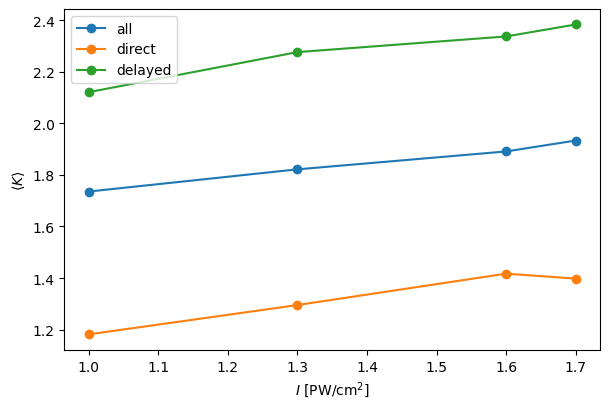

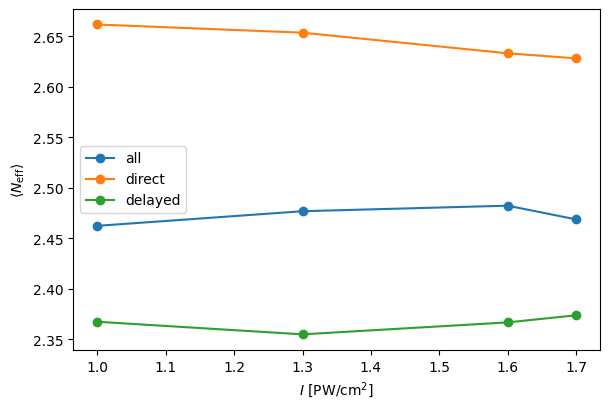

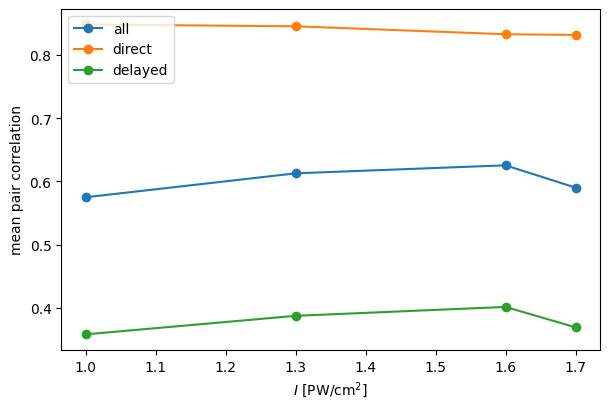

In [12]:
# Main trends across the four field intensities
trend_metrics = {
    'mean_K': r'$\langle K\rangle$',
    'mean_N_eff': r'$\langle N_{\mathrm{eff}}\rangle$',
    'mean_pair_correlation': 'mean pair correlation',
}

for metric, ylabel in trend_metrics.items():
    plt.figure(figsize=(6.2, 4.2))
    for event_class in EVENT_CLASSES:
        current = summary[summary['event_class'] == event_class].sort_values('intensity')
        plt.plot(current['intensity'], current[metric], marker='o', label=event_class)
    plt.xlabel(r'$I$ [PW/cm$^2$]')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'trend_{metric}.png', dpi=DPI)
    plt.show()


In [13]:
def intensity_tag(intensity):
    return str(intensity).replace('.', 'p')

def class_data(intensity, event_class):
    return processed[(float(intensity), event_class)]

def save_relative_plane(intensity):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
    all_df = class_data(intensity, 'all')
    x_range = (all_df['xi1'].min(), all_df['xi1'].max())
    y_range = (all_df['xi2'].min(), all_df['xi2'].max())
    for ax, event_class in zip(axes, EVENT_CLASSES):
        df = class_data(intensity, event_class)
        ax.hist2d(df['xi1'], df['xi2'], bins=BINS_2D, range=[x_range, y_range], density=True)
        ax.set_title(event_class)
        ax.set_xlabel(r'$\xi_1$')
        ax.set_ylabel(r'$\xi_2$')
    fig.suptitle(fr'$I={intensity:g}$ PW/cm$^2$')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'relative_plane_{intensity_tag(intensity)}.png', dpi=DPI)
    plt.close(fig)

def save_Pe_vs_K(intensity):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
    all_df = class_data(intensity, 'all')
    x_range = (all_df['P_e'].min(), all_df['P_e'].max())
    y_range = (all_df['K'].min(), all_df['K'].max())
    for ax, event_class in zip(axes, EVENT_CLASSES):
        df = class_data(intensity, event_class)
        ax.hist2d(df['P_e'], df['K'], bins=BINS_2D, range=[x_range, y_range], density=True)
        ax.set_title(event_class)
        ax.set_xlabel(r'$P_e$')
        ax.set_ylabel(r'$K$')
    fig.suptitle(fr'$I={intensity:g}$ PW/cm$^2$')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'P_vs_K_{intensity_tag(intensity)}.png', dpi=DPI)
    plt.close(fig)

def save_Neff(intensity):
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    bins = np.linspace(1.0, 3.0, BINS_1D + 1)
    for event_class in EVENT_CLASSES:
        df = class_data(intensity, event_class)
        ax.hist(df['N_eff'].dropna(), bins=bins, density=True, histtype='step', label=event_class)
    ax.set_xlabel(r'$N_{\mathrm{eff}}$')
    ax.set_ylabel('density')
    ax.set_title(fr'$I={intensity:g}$ PW/cm$^2$')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'Neff_{intensity_tag(intensity)}.png', dpi=DPI)
    plt.close(fig)

def save_sign_sectors(intensity):
    order = ['+++', '++-', '+-+', '-++', '+--', '-+-', '--+', '---']
    current = sector_counts[sector_counts['intensity'] == intensity]
    pivot = current.pivot(index='sign_sector', columns='event_class', values='fraction').reindex(order).fillna(0.0)
    ax = pivot[EVENT_CLASSES].plot(kind='bar', figsize=(8.2, 4.3))
    ax.set_xlabel('sign sector')
    ax.set_ylabel('fraction')
    ax.set_title(fr'$I={intensity:g}$ PW/cm$^2$')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'sign_sectors_{intensity_tag(intensity)}.png', dpi=DPI)
    plt.close()

def save_ilr(intensity):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
    all_df = class_data(intensity, 'all')
    x_range = (all_df['ilr1'].quantile(0.005), all_df['ilr1'].quantile(0.995))
    y_range = (all_df['ilr2'].quantile(0.005), all_df['ilr2'].quantile(0.995))
    for ax, event_class in zip(axes, EVENT_CLASSES):
        df = class_data(intensity, event_class)
        ax.hist2d(df['ilr1'], df['ilr2'], bins=BINS_2D, range=[x_range, y_range], density=True)
        ax.set_title(event_class)
        ax.set_xlabel(r'$y_1$')
        ax.set_ylabel(r'$y_2$')
    fig.suptitle(fr'$I={intensity:g}$ PW/cm$^2$')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'ilr_{intensity_tag(intensity)}.png', dpi=DPI)
    plt.close(fig)

def save_correlations(intensity):
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
    for ax, event_class in zip(axes, EVENT_CLASSES):
        df = class_data(intensity, event_class)
        corr = df[['p2z', 'p3z', 'p4z']].corr()
        image = ax.imshow(corr.to_numpy(), vmin=-1.0, vmax=1.0)
        ax.set_xticks(range(3), ['p2z', 'p3z', 'p4z'])
        ax.set_yticks(range(3), ['p2z', 'p3z', 'p4z'])
        ax.set_title(event_class)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
    fig.colorbar(image, ax=axes, fraction=0.025, pad=0.04)
    fig.suptitle(fr'$I={intensity:g}$ PW/cm$^2$')
    fig.subplots_adjust(top=0.82, wspace=0.35)
    fig.savefig(FIGURE_DIR / f'correlations_{intensity_tag(intensity)}.png', dpi=DPI)
    plt.close(fig)

for intensity in INTENSITIES:
    save_relative_plane(intensity)
    save_Pe_vs_K(intensity)
    save_Neff(intensity)
    save_sign_sectors(intensity)
    save_ilr(intensity)
    save_correlations(intensity)

print(f'Detailed figures saved to: {FIGURE_DIR.resolve()}')


Detailed figures saved to: C:\Users\koran\Documents\UJ\Semestr 4\praktyka\praca-licencjacka\praca-licencjacka\momentum_sharing_results\figures


In [14]:
# Export compact numerical results for the thesis
summary.to_csv(OUTPUT_DIR / 'summary_all_intensities.csv', index=False)
validation.to_csv(OUTPUT_DIR / 'validation_all_intensities.csv', index=False)
sector_counts.to_csv(OUTPUT_DIR / 'sign_sectors_all_intensities.csv', index=False)
correlations.to_csv(OUTPUT_DIR / 'correlations_all_intensities.csv', index=False)
direct_delayed.to_csv(OUTPUT_DIR / 'direct_delayed_comparison.csv', index=False)

print(f'Tables saved to: {OUTPUT_DIR.resolve()}')


Tables saved to: C:\Users\koran\Documents\UJ\Semestr 4\praktyka\praca-licencjacka\praca-licencjacka\momentum_sharing_results
